# 🧠 AI Workout Coach - Semantic Vector Search Evaluation

This notebook evaluates the **hybrid retrieval search** (FAISS semantic indexing + NumPy TF-IDF keyword ranking) and **Cross-Encoder reranking** system used in the AI Workout Coach database storage.

### 📈 Retrieval Methodology
1. **Semantic Search (FAISS FlatIP)**: Uses the `nomic-embed-text-v1.5` model to encode queries and documents. Computes Cosine Similarity utilizing L2-normalized vector inner products.
2. **Lexical Search (NumPy TF-IDF)**: Standard keyword matching fallback using term-frequency inverse-document-frequency values.
3. **Hybrid Score Fusion**: Blends scores with a weighted ratio of **70% Semantic + 30% Keyword**.
4. **Threshold Filtering**: Only candidates with a combined hybrid score `>= 0.35` are retained.
5. **Cross-Encoder Reranking**: The top 15 candidates are reranked using the `cross-encoder/ms-marco-MiniLM-L-6-v2` model (90% weight) combined with a recency decay boost (10% weight).

### 🔬 Evaluation Dataset Structure
- **50 Stored Memories**: Ground-truth user facts covering weekly schedules, body-composition assessments, injuries, dietary targets, and recovery habits.
- **200 Paraphrased Queries**: 4 diverse variations per memory (semantic paraphrasing, keyword emphasis, short queries) to evaluate query robustness.
- **50 Distractor Queries**: Unrelated general knowledge questions (capital cities, economics, coding, etc.) to verify threshold filter reliability (FPR).

In [1]:
# 1. Initialize environments and import modules
import os
import sys
import time
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent workspace directory to sys.path to resolve imports correctly
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)
import database
print("Embedding Model status:", database.get_db_status())

d:\Data Science\LLM-Memory\.mem-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding Model status: {'faiss_available': True, 'faiss_library': 'Available', 'sentence_transformers_library': 'Available', 'model_loaded': 'No', 'total_records': 119, 'records_with_vectors': 119, 'active_users': 2, 'memory_tags': ['semantic', 'episodic', 'procedural'], 'engine_mode': 'FAISS (Semantic)'}


In [2]:
# 2. Import the evaluation dataset from our test module
from test_semantic_search import TEST_MEMORIES, EVAL_QUERIES, DISTRACTOR_QUERIES
print(f"Loaded {len(TEST_MEMORIES)} ground-truth memories, {len(EVAL_QUERIES)} paraphrased queries, and {len(DISTRACTOR_QUERIES)} distractors.")

Loaded 50 ground-truth memories, 200 paraphrased queries, and 50 distractors.


In [3]:
# 3. Populate test database and index vectors
test_user = "eval_athlete_notebook"

# Clear out existing test athlete rows
conn = sqlite3.connect(database.DB_PATH)
c = conn.cursor()
c.execute("DELETE FROM memories WHERE username = ?", (test_user,))
conn.commit()
conn.close()

print("Populating memories (generating embeddings)...")
db_id_map = {}
for idx, mem in enumerate(TEST_MEMORIES):
    database.save_memory(
        username=test_user,
        tag=mem["tag"],
        query=mem["q"],
        response=mem["r"],
        subtag="implicit"
    )
    
    conn = sqlite3.connect(database.DB_PATH)
    c = conn.cursor()
    c.execute("SELECT max(id) FROM memories WHERE username = ?", (test_user,))
    db_id_map[mem["id"]] = c.fetchone()[0]
    conn.close()
    if (idx + 1) % 10 == 0:
        print(f"  Indexed {idx+1}/{len(TEST_MEMORIES)} memories...")

print(f"Success! Populated evaluation database with {len(db_id_map)} records.")

Populating memories (generating embeddings)...


<All keys matched successfully>
[transformers] Detected the usage of `get_extended_attention_mask`: This function is deprecated and will be removed in v5.12.0. Please use the new API in `transformers.masking_utils`


  Indexed 10/50 memories...
  Indexed 20/50 memories...
  Indexed 30/50 memories...
  Indexed 40/50 memories...
  Indexed 50/50 memories...
Success! Populated evaluation database with 50 records.


In [4]:
# 4. Run retrieval evaluation loop
print("Running paraphrased query tests...")
latencies = []
ranks = []
threshold_misses = 0

for idx, q_case in enumerate(EVAL_QUERIES):
    target_id = q_case["target_id"]
    tag = q_case["tag"]
    query_text = q_case["query"]
    expected_id = db_id_map[target_id]
    
    t_start = time.time()
    results = database.vector_query_memories(test_user, tag, query_text, top_k=5)
    latencies.append((time.time() - t_start) * 1000.0)
    
    retrieved_ids = [r["id"] for r in results]
    if expected_id in retrieved_ids:
        ranks.append(retrieved_ids.index(expected_id) + 1)
    else:
        ranks.append(-1)
        if not results:
            threshold_misses += 1
            
    if (idx + 1) % 40 == 0:
        print(f"  Evaluated {idx+1}/{len(EVAL_QUERIES)} queries...")
            
print("\nRunning distractor query tests (threshold safety)...")
distractor_latencies = []
false_positives = 0
for idx, dist_q in enumerate(DISTRACTOR_QUERIES):
    t_start = time.time()
    res_sem = database.vector_query_memories(test_user, "semantic", dist_q, top_k=1)
    res_epi = database.vector_query_memories(test_user, "episodic", dist_q, top_k=1)
    res_pro = database.vector_query_memories(test_user, "procedural", dist_q, top_k=1)
    distractor_latencies.append((time.time() - t_start) * 1000.0)
    if res_sem or res_epi or res_pro:
        false_positives += 1
        
    if (idx + 1) % 15 == 0:
        print(f"  Checked {idx+1}/{len(DISTRACTOR_QUERIES)} distractors...")

print("\nEvaluation loop complete.")

Running paraphrased query tests...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1306.44it/s]


  Evaluated 40/200 queries...
  Evaluated 80/200 queries...
  Evaluated 120/200 queries...
  Evaluated 160/200 queries...
  Evaluated 200/200 queries...

Running distractor query tests (threshold safety)...
  Checked 15/50 distractors...
  Checked 30/50 distractors...
  Checked 45/50 distractors...

Evaluation loop complete.


In [5]:
# 5. Calculate and display metrics
total_queries = len(EVAL_QUERIES)
top_1 = sum(1 for r in ranks if r == 1)
top_3 = sum(1 for r in ranks if 1 <= r <= 3)
top_5 = sum(1 for r in ranks if 1 <= r <= 5)

acc_top1 = (top_1 / total_queries) * 100
acc_top3 = (top_3 / total_queries) * 100
acc_top5 = (top_5 / total_queries) * 100
fpr = (false_positives / len(DISTRACTOR_QUERIES)) * 100

all_latencies = latencies + distractor_latencies

print("===============================================")
print("SEMANTIC VECTOR SEARCH RETRIEVAL PERFORMANCE")
print("===============================================")
print(f"Top-1 Accuracy:  {acc_top1:.2f}% ({top_1}/{total_queries})")
print(f"Top-3 Accuracy:  {acc_top3:.2f}% ({top_3}/{total_queries})")
print(f"Top-5 Accuracy:  {acc_top5:.2f}% ({top_5}/{total_queries})")
print(f"Threshold Misses: {threshold_misses}/{total_queries} (Query fell below 0.35)")
print(f"False Positives:  {false_positives}/{len(DISTRACTOR_QUERIES)} (FPR: {fpr:.2f}%)")
print("-----------------------------------------------")
print(f"Average Latency: {np.mean(all_latencies):.2f} ms")
print(f"Median Latency:  {np.median(all_latencies):.2f} ms")
print(f"95th Percentile: {np.percentile(all_latencies, 95):.2f} ms")
print(f"99th Percentile: {np.percentile(all_latencies, 99):.2f} ms")
print("===============================================")

SEMANTIC VECTOR SEARCH RETRIEVAL PERFORMANCE
Top-1 Accuracy:  92.00% (184/200)
Top-3 Accuracy:  93.00% (186/200)
Top-5 Accuracy:  93.00% (186/200)
Threshold Misses: 11/200 (Query fell below 0.35)
False Positives:  0/50 (FPR: 0.00%)
-----------------------------------------------
Average Latency: 320.74 ms
Median Latency:  270.29 ms
95th Percentile: 433.92 ms
99th Percentile: 688.03 ms


In [10]:
EVAL_QUERIES

[{'target_id': 1,
  'tag': 'semantic',
  'query': 'Who is my coach and when do we meet up?'},
 {'target_id': 1,
  'tag': 'semantic',
  'query': 'Details about my training schedule with Marcus'},
 {'target_id': 1,
  'tag': 'semantic',
  'query': 'What day do I have a personal training session at 5 PM?'},
 {'target_id': 1,
  'tag': 'semantic',
  'query': 'When is my workout appointment with Marcus?'},
 {'target_id': 2,
  'tag': 'semantic',
  'query': 'What did my fitness evaluation show?'},
 {'target_id': 2,
  'tag': 'semantic',
  'query': 'June 12 body fat measurement records'},
 {'target_id': 2,
  'tag': 'semantic',
  'query': 'My body fat percent from my latest assessment'},
 {'target_id': 2,
  'tag': 'semantic',
  'query': 'When did I measure my body composition?'},
 {'target_id': 3,
  'tag': 'semantic',
  'query': 'What time do I prefer to work out in the morning?'},
 {'target_id': 3,
  'tag': 'semantic',
  'query': 'Do I train before going to work?'},
 {'target_id': 3,
  'tag': 'se

### Custom Queries

In [9]:
from query_test import run_debug_search

# 1. Choose your query and tag
my_query = "Am I vegetarian and what are my protein sources?"
my_tag = "semantic"  # Try: "semantic", "episodic", or "procedural"

# 2. Run the diagnostic search (using the athlete user populated in Cell 3)
run_debug_search("eval_athlete_notebook", my_tag, my_query)



🔎 DIAGNOSTIC SEARCH REPORT FOR: "Am I vegetarian and what are my protein sources?"
👤 User: eval_athlete_notebook | Tag: SEMANTIC

🟢 PASSED RELEVANCE THRESHOLD (hybrid >= 0.48 or semantic >= 0.60) - 1 matches found:

Rank #1: [Memory ID: 386] (Subtag: implicit)
  Query:    "What are your dietary preferences?"
  Response: "My dietary preference is vegetarian high-protein, eating plenty of tofu, tempeh, and red lentils."
  Score Breakdown:
  ├─ Semantic Score (FAISS):    0.7209  (Weight: 70%)
  ├─ Lexical Score (TF-IDF):    0.3601  (Weight: 30%)
  ├─ Hybrid Score (Combined):   0.6127  (Threshold: >= 0.48 or Semantic >= 0.60) -> PASSED
  ├─ Cross-Encoder Rerank:      0.9082  (Weight: 70%)
  ├─ Metadata Boost (Combined): 0.3969  (Weight: 30%)
  │  ├─ Explicit Subtag Boost: 0.0000  (Weight: 60%)
  │  └─ Recency Boost (7d half):0.9922  (Weight: 40%)
  └─ Final Reranked Score:      0.7548

----------------------------------------------------------------------
🔴 FILTERED OUT / IRRELEVANT (hybr

In [7]:
from query_test import run_debug_search

# 1. Type a query that matches onboarding/explicit memories 
# (e.g. pain/injury queries like "deadlift back pain" which are explicit)
# my_query = "Trees are green in color"
# my_query = 'teacher is taking the class of Algebra'

# my_query = 'Alas! We have been talking to ghosts till now'

# my_query = "i have only vegan items"
# my_query = "Am I a vegetarian or do I eat meat?"
my_query = "I will have healthy food only"


my_tag = "semantic"  

# 2. Run the diagnostic search
run_debug_search("eval_athlete_notebook", my_tag, my_query)



🔎 DIAGNOSTIC SEARCH REPORT FOR: "I will have healthy food only"
👤 User: eval_athlete_notebook | Tag: SEMANTIC

🟢 PASSED RELEVANCE THRESHOLD (hybrid >= 0.48 or semantic >= 0.60) - 0 matches found:
  (No memories matched your query above the relevance threshold)

----------------------------------------------------------------------
🔴 FILTERED OUT / IRRELEVANT (hybrid < 0.48 and semantic < 0.60, or CE/keyword < 0.30) - showing top 5 closest distractors:

Distractor #1: [Memory ID: 379] (Subtag: implicit)
  Query:    "Do you have asthma?"
  Response: "I have mild exercise-induced asthma. Always keep my inhaler in my gym bag."
  Score Breakdown:
  ├─ Semantic Score (FAISS):    0.4852
  ├─ Lexical Score (TF-IDF):    0.2886
  ├─ Hybrid Score (Combined):   0.4262
  └─ Hybrid Score (Combined):   0.4262  (Threshold: >= 0.48 or Semantic >= 0.60) -> FAILED

Distractor #2: [Memory ID: 386] (Subtag: implicit)
  Query:    "What are your dietary preferences?"
  Response: "My dietary preference is ve

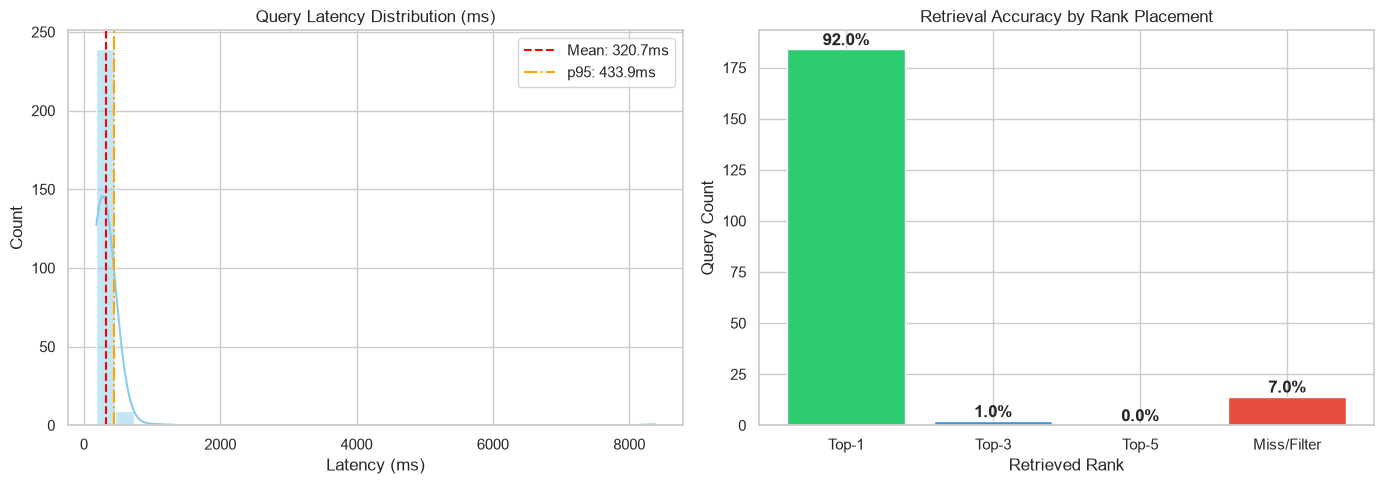

In [8]:
# 6. Plot performance distributions
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Latency Distribution
plt.subplot(1, 2, 1)
sns.histplot(all_latencies, kde=True, bins=30, color="skyblue")
plt.axvline(np.mean(all_latencies), color="red", linestyle="--", label=f"Mean: {np.mean(all_latencies):.1f}ms")
plt.axvline(np.percentile(all_latencies, 95), color="orange", linestyle="-.", label=f"p95: {np.percentile(all_latencies, 95):.1f}ms")
plt.title("Query Latency Distribution (ms)")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.legend()

# Retrieval Accuracy by Rank
plt.subplot(1, 2, 2)
categories = ['Top-1', 'Top-3', 'Top-5', 'Miss/Filter']
counts = [
    top_1,
    top_3 - top_1,
    top_5 - top_3,
    total_queries - top_5
]
colors = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]
plt.bar(categories, counts, color=colors)
plt.title("Retrieval Accuracy by Rank Placement")
plt.xlabel("Retrieved Rank")
plt.ylabel("Query Count")
for i, val in enumerate(counts):
    pct = (val / total_queries) * 100
    plt.text(i, val + 2, f"{pct:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()